<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
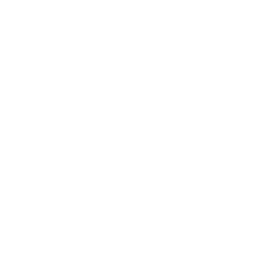
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Healthcare Diagnosis Category Mix</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Healthcare / Clinical Operations &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

Visualize the distribution of primary diagnosis categories across a sample of emergency department encounters using a donut chart. PROC SGPIE with the DONUT statement displays patient volume by diagnosis-category grouping from 100 ED visits. DATALABELS print each slice's category, and OTHERPERCENT=4 consolidates any category below 4% of volume into a single 'Other' slice so the chart stays readable. ODS OUTPUT captures the same chart a second time, and PROC MEANS then profiles length-of-stay (LOS) by diagnosis group. The result is a compact volume-and-acuity view suitable for an ED operations dashboard.

## Data Sources

| Source | Description | Records |
|--------|-------------|--------|
| WORK.ED_VISITS | Emergency department encounter records | 100 |

---

In [1]:
/* --------------------------------------------------------
   Generate synthetic ED visit records
   100 encounters with diagnosis categories and LOS
   -------------------------------------------------------- */
data work.ed_visits;
    call streaminit(42);
    length dx_category $25 acuity $10 disposition $15;
    array dx_cats[9] $25 _temporary_ ('Injury & Trauma' 'Cardiovascular' 'Respiratory' 'Gastrointestinal' 'Neurological' 'Musculoskeletal' 'Infectious Disease' 'Mental Health' 'Genitourinary');
    array dx_weights[9] _temporary_ (0.22 0.15 0.14 0.12 0.10 0.08 0.08 0.06 0.05);
    array acuities[5] $10 _temporary_ ('ESI-1' 'ESI-2' 'ESI-3' 'ESI-4' 'ESI-5');
    array disps[4] $15 _temporary_ ('Discharged' 'Admitted' 'Observation' 'Transferred');
    do encounter_id = 1 to 100;
        patient_id = cat('P-', put(int(rand('uniform') * 3500) + 1, z6.));
        rand_val = rand('uniform');
        cumulative = 0;
        do d = 1 to 9;
            cumulative + dx_weights[d];
            if rand_val <= cumulative then do;
                dx_category = dx_cats[d];
                leave;
            end;
        end;
        acuity_idx = int(rand('uniform') * 5) + 1;
        acuity = acuities[acuity_idx];
        disp_idx = int(rand('uniform') * 4) + 1;
        disposition = disps[disp_idx];
        los_hours = round(rand('exponential') * 4 + 0.5, 0.1);
        if acuity in ('ESI-1' 'ESI-2') then los_hours = los_hours * 2.5;
        arrival_date = '01JAN2026'd + int(rand('uniform') * 90);
        output;
    end;
    drop rand_val cumulative d acuity_idx disp_idx;
    format arrival_date date9.;
run;

NOTE: DATA work.ed_visits


NOTE: Wrote work.ed_visits (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

                                         ED Visit Volume by Diagnosis Category                                          

                                                   The FREQ Procedure

dx_category           Frequency    Percent
-------------------------------------------
Gastrointestinal             24     24.00
Injury & Trauma              22     22.00
Neurological                 13     13.00
Cardiovascular               11     11.00
Respiratory                   9      9.00
Musculoskeletal               8      8.00
Infectious Disease            6      6.00
Genitourinary                 5      5.00
Mental Health                 2      2.00


NOTE: PROC FREQ
NOTE: ODS plot written: freq_dx_category.spec.json
NOTE: PROC FREQ statement used.


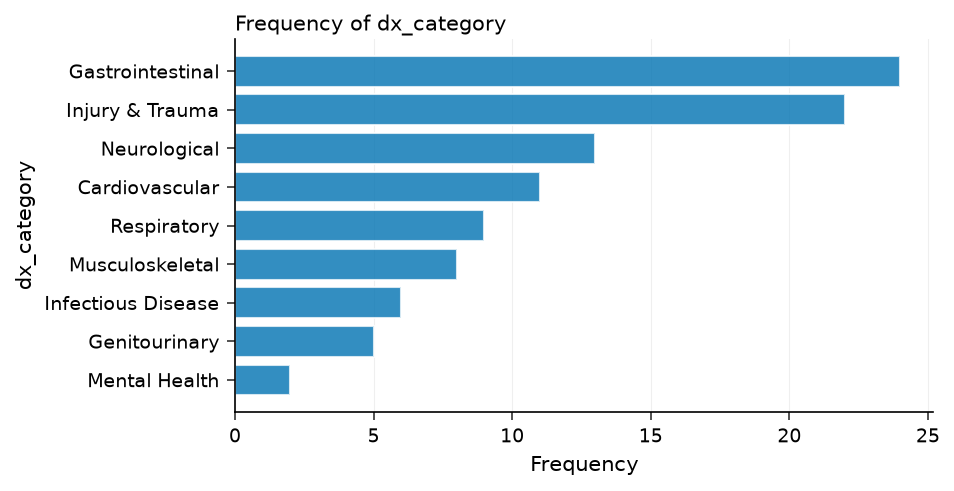

In [2]:
/* --------------------------------------------------------
   Baseline encounter volume by diagnosis category
   -------------------------------------------------------- */
proc freq data=work.ed_visits order=freq;
    tables dx_category / nocum;
    title 'ED Visit Volume by Diagnosis Category';
run;

---

                                         ED Visit Volume by Diagnosis Category                                          



NOTE: PROC SGPIE data=work.ed_visits

NOTE: PROC SGPIE output written to: ./ods_output/sgpie.svg


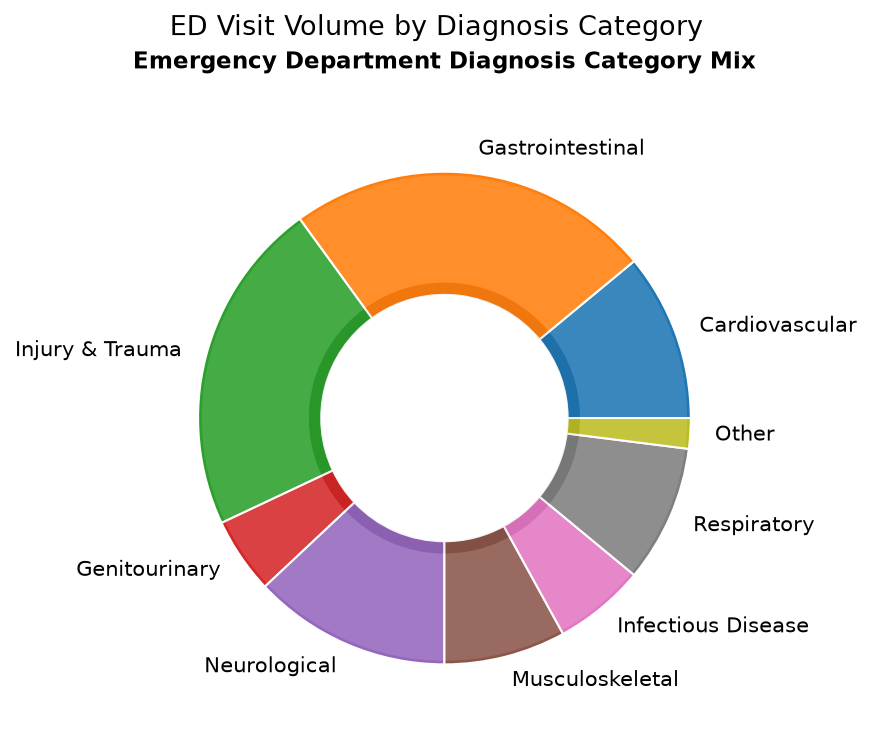

In [3]:
/* --------------------------------------------------------
   Donut chart of diagnosis mix
   -------------------------------------------------------- */
proc sgpie data=work.ed_visits;
    donut dx_category / datalabels
        otherpercent=4
        dataskin=matte;
    title 'Emergency Department Diagnosis Category Mix';
run;

---

                                         ED Visit Volume by Diagnosis Category                                          



NOTE: ODS OUTPUT: SGPIE -> dx_pcts
NOTE: PROC SGPIE data=work.ed_visits

NOTE: PROC SGPIE output written to: ./ods_output/sgpie.svg
NOTE: ODS OUTPUT: All output destinations closed.


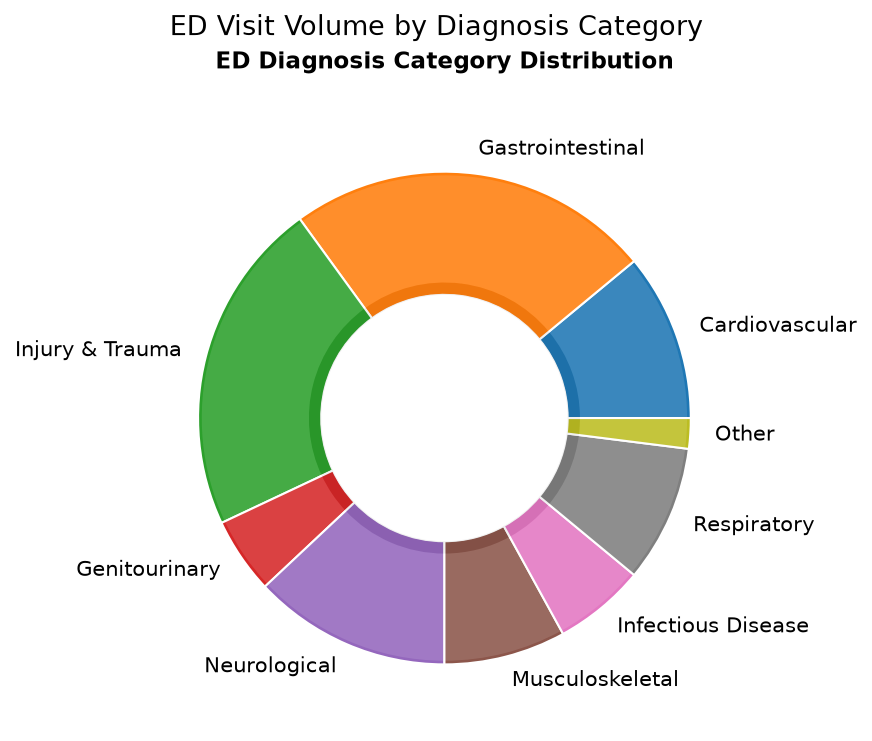

In [4]:
/* --------------------------------------------------------
   Donut chart with ODS OUTPUT to capture percentages
   -------------------------------------------------------- */
ods output sgpie=work.dx_pcts;

proc sgpie data=work.ed_visits;
    donut dx_category / datalabels
        otherpercent=4
        dataskin=matte;
    title 'ED Diagnosis Category Distribution';
run;

ods output close;

In [5]:
/* --------------------------------------------------------
   Profile length-of-stay by diagnosis group with PROC MEANS
   -------------------------------------------------------- */
proc sort data=work.ed_visits;
    by dx_category;
run;

proc means data=work.ed_visits n mean median std max;
    by dx_category;
    var los_hours;
    output out=work.los_by_dx
        n=n_encounters mean=mean_los median=median_los std=std_los max=max_los;
    title 'Length of Stay by Diagnosis Category';
run;

                                          Length of Stay by Diagnosis Category                                          

---------------------------------------------- dx_category=Cardiovascular ----------------------------------------------

                                                  The MEANS Procedure

 Variable         N           Mean         Median        Std Dev        Maximum
 ------------------------------------------------------------------------------
 los_hours       11      9.3454545     10.5000000      6.1855660     21.4000000
 ------------------------------------------------------------------------------


--------------------------------------------- dx_category=Gastrointestinal ---------------------------------------------

                                                  The MEANS Procedure

 Variable         N           Mean         Median        Std Dev        Maximum
 ------------------------------------------------------------------------------
 los_hours

NOTE: PROC SORT data=work.ed_visits

NOTE: Read 100 rows from work.ed_visits.
NOTE: Wrote work.ed_visits (100 rows, 7 columns).
NOTE: PROC SORT statement used.
NOTE: PROC MEANS
NOTE: Output dataset work.los_by_dx has 9 observations and 8 variables.
NOTE: PROC MEANS statement used.


---

### Interpretation

Across these 100 sampled encounters, Gastrointestinal complaints form the largest slice at 24%, followed closely by Injury & Trauma at 22%. Neurological (13%) and Cardiovascular (11%) round out the high-volume categories, with Respiratory (9%), Musculoskeletal (8%), Infectious Disease (6%), and Genitourinary (5%) trailing. Mental Health sits at just 2% of volume and, falling below the OTHERPERCENT=4 threshold, is consolidated into the donut's 'Other' slice rather than shown on its own; every other category clears 4% and keeps its own slice.

Length-of-stay profiling via PROC MEANS shows the acuity story behind the volume. Mental Health encounters carry the longest mean LOS at 15.5 hours (n=2) and Musculoskeletal the next longest at 13.3 hours, both inflated by a handful of high-acuity ESI-1/ESI-2 cases that receive the 2.5x LOS multiplier; Injury & Trauma (9.6 hours) and Cardiovascular (9.3 hours) follow. The shortest stays belong to Infectious Disease (3.1 hours) and Genitourinary (3.6 hours). Because several categories rest on small counts, these LOS figures are illustrative of the workflow rather than population estimates, but they demonstrate how a single SGPIE volume chart pairs with PROC MEANS to support ED staffing and bed-management decisions.

---

In [6]:
/* --------------------------------------------------------
   Export LOS profile for clinical operations dashboard
   -------------------------------------------------------- */
proc export data=work.los_by_dx
    outfile='ed_los_by_diagnosis.csv'
    dbms=csv replace;
run;

NOTE: PROC EXPORT data=work.los_by_dx outfile=ed_los_by_diagnosis.csv

NOTE: Exported 9 rows to ed_los_by_diagnosis.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>